# U15 — Regression (finish): Lab

### Real-world brief: forecasting wind-turbine energy yield

A wind-farm operator wants to predict a turbine's **daily energy output (kWh)** from weather and operating conditions — for scheduling, maintenance planning and performance monitoring. The signal is **nonlinear** (power grows with the cube of wind speed, then saturates), the target is **skewed**, and a few sensor glitches create outliers. You'll diagnose, transform, regularise and finally beat the linear model with tree ensembles.

**Resource provided:** `turbine_energy.csv` (one row per turbine-day). Keep it beside this notebook (upload it in Colab).

_Phase D — Modelling (Regression, Part 2)._

#objectives

Diagnose a fit with residual plots and a Q-Q plot

Fix skew and curvature with a target/feature transform

Compare Ridge, Lasso and ElasticNet, and tune the strength

Detect and blunt the effect of outliers

Beat the linear baseline with random forest / gradient boosting, then tune it

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [ ]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_turbine(csv_path="turbine_energy.csv", seed=152, verbose=False):
    """Wind-turbine daily energy yield — a nonlinear regression with a skewed target,
    correlated features, an outlier-prone signal and a feature that needs transforming.
    Ideal for residual diagnostics, transforms, regularisation and tree ensembles.

    Features:
      wind_speed_ms        average wind speed (m/s)
      wind_std_ms          gustiness (std of wind speed)
      air_density_kgm3     air density (kg/m^3)
      turbulence_intensity fraction (0-1)
      blade_pitch_deg      blade pitch angle (deg)
      rotor_rpm            rotor speed (rpm)
      ambient_temp_c       ambient temperature (deg C)
      turbine_age_years    age of the turbine (years)
    Target:
      energy_kwh           daily energy produced (kWh) — right-skewed
    """
    rng = np.random.default_rng(seed)
    N = 1600
    wind = np.clip(rng.weibull(2.0, N) * 7.0, 0.5, 26)          # Weibull -> right-skew
    wind_std = np.clip(0.12 * wind + rng.normal(0, 0.3, N), 0.05, None)
    density = np.clip(rng.normal(1.225, 0.04, N), 1.10, 1.35)
    turb = np.clip(rng.normal(0.14, 0.05, N), 0.02, 0.40)
    pitch = np.clip(rng.normal(4, 6, N), -2, 25)
    rpm = np.clip(8 + 0.9 * wind + rng.normal(0, 1.5, N), 4, 30)  # correlated with wind
    temp = rng.normal(15, 9, N).round(1)
    age = rng.uniform(0, 20, N)

    # power ~ density * v^3 up to rated, then flattens; losses from pitch, turbulence, age
    cube = np.minimum(wind, 13) ** 3                              # cubic then saturates near rated
    rated_extra = np.maximum(wind - 13, 0) * 120
    energy = (density * (3.1 * cube + rated_extra)
              - 35 * np.abs(pitch - 2)
              - 1800 * turb
              - 22 * age
              + rng.normal(0, 280, N))
    energy = np.clip(energy, 0, None)
    # a few sensor-glitch outliers
    g = rng.choice(N, 18, replace=False)
    energy[g] = energy[g] * rng.uniform(1.6, 2.4, len(g))

    df = pd.DataFrame({
        "wind_speed_ms": wind.round(2), "wind_std_ms": wind_std.round(2),
        "air_density_kgm3": density.round(3), "turbulence_intensity": turb.round(3),
        "blade_pitch_deg": pitch.round(1), "rotor_rpm": rpm.round(1),
        "ambient_temp_c": temp, "turbine_age_years": age.round(1),
        "energy_kwh": energy.round(1),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        from scipy.stats import skew
        print("turbine:", df.shape)
        print("energy range:", df.energy_kwh.min(), "-", df.energy_kwh.max())
        print("target skew:", round(skew(df.energy_kwh), 2))
        print("corr(wind, energy):", round(df.wind_speed_ms.corr(df.energy_kwh), 3))
        print("corr(wind, rpm):", round(df.wind_speed_ms.corr(df.rotor_rpm), 3))
    return df

if not os.path.exists('turbine_energy.csv'):
    build_turbine(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv('turbine_energy.csv')
TARGET = 'energy_kwh'
features = [c for c in df.columns if c != TARGET]
X = df[features].values; y = df[TARGET].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('shape:', df.shape, '| features:', len(features))
df.head(3)

shape: (1600, 9) | features: 8


,wind_speed_ms,wind_std_ms,air_density_kgm3,turbulence_intensity,blade_pitch_deg,rotor_rpm,ambient_temp_c,turbine_age_years,energy_kwh
0,4.95,0.81,1.238,0.185,-1.2,13.1,2.4,2.7,0.0
1,6.83,0.84,1.265,0.169,-2.0,15.3,12.1,5.9,527.2
2,1.44,0.05,1.225,0.114,-2.0,7.3,26.1,1.2,0.0


#1. Baseline & residual diagnostics

baseline RMSE: 1032.5 kWh | R2: 0.727


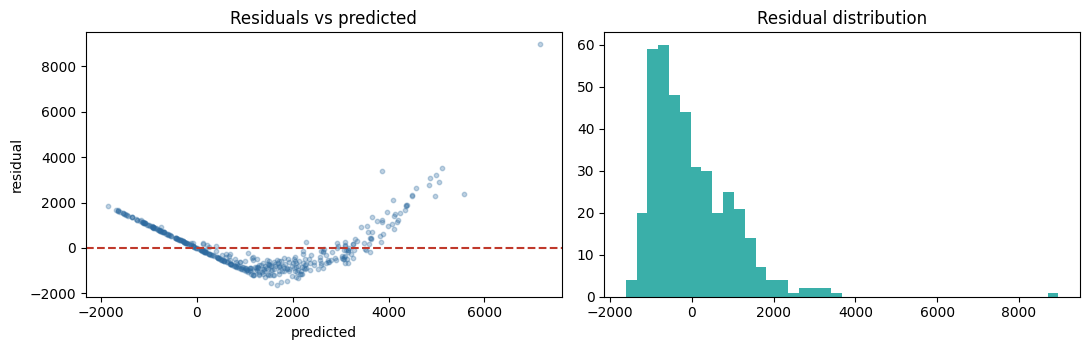

Look for curvature / a fan shape (heteroscedasticity) and skewed residuals.


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. LINEAR BASELINE + RESIDUAL PLOT
# -----------------------------------------------------------
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)
resid = y_test - pred
print(f'baseline RMSE: {mean_squared_error(y_test, pred) ** 0.5:.1f} kWh | R2: {r2_score(y_test, pred):.3f}')
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].scatter(pred, resid, s=10, alpha=0.3, color='#2D6A9F')
ax[0].axhline(0, color='#C0392B', ls='--'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('residual')
ax[0].set_title('Residuals vs predicted')
ax[1].hist(resid, bins=40, color='#3AAFA9'); ax[1].set_title('Residual distribution')
plt.tight_layout(); plt.show()
print('Look for curvature / a fan shape (heteroscedasticity) and skewed residuals.')

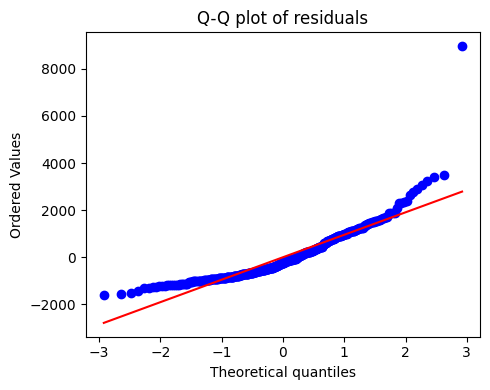

Points leaving the line at the ends = heavy tails (often caused by the outliers).


In [ ]:
# -----------------------------------------------------------
# 🔹 1B. Q-Q PLOT — ARE THE ERRORS NORMAL?
# -----------------------------------------------------------
from scipy import stats
fig, ax = plt.subplots(figsize=(5, 4))
stats.probplot(resid, dist='norm', plot=ax)
ax.set_title('Q-Q plot of residuals'); plt.tight_layout(); plt.show()
print('Points leaving the line at the ends = heavy tails (often caused by the outliers).')

#### 🧪 EXERCISE 1 — Name the problem
Look at the residuals-vs-predicted plot.
1. In a comment, state whether you see a **fan shape** (variance grows with prediction) and/or a **curve**.
2. Compute the skew of the **target** with `scipy.stats.skew(y)` — is it right-skewed (skew > 1)?

In [ ]:
from scipy.stats import skew
# 1. describe the residual pattern: I see a clear curve in the residuals vs predicted plot, and the variance appears to increase with the predicted values, indicating a fan shape.

# 2. skew of the target
print(f'Skew of target (y): {skew(y):.2f}')

Skew of target (y): 2.21


#2. Fix it with a transform

In [ ]:
# -----------------------------------------------------------
# 🔹 2A. PHYSICS-INFORMED FEATURE TRANSFORM (power ~ wind^3)
# -----------------------------------------------------------
# The residual curve comes from the cubic wind->power law. Add wind^2 and wind^3.
wi = features.index('wind_speed_ms')
def add_wind_poly(M):
    w = M[:, wi:wi + 1]
    return np.hstack([M, w ** 2, w ** 3])
Xtr_aug, Xte_aug = add_wind_poly(X_train), add_wind_poly(X_test)
lin_aug = LinearRegression().fit(Xtr_aug, y_train)
pred_aug = lin_aug.predict(Xte_aug)
print(f'baseline           R2: {r2_score(y_test, pred):.3f}')
print(f'+ wind^2, wind^3   R2: {r2_score(y_test, pred_aug):.3f}')
print('Matching the feature to the physics straightens the relationship.')

baseline           R2: 0.727
+ wind^2, wind^3   R2: 0.935
Matching the feature to the physics straightens the relationship.


#### 🧪 EXERCISE 2 — Did the curve disappear?
1. Plot residuals vs `wind_speed_ms` (the test rows) for the **baseline** model.
2. Plot the same for the **augmented** model (with wind² and wind³).
3. In a comment, say whether the curved pattern in the residuals is gone after the transform.
*(Optional, advanced: try log-transforming the skewed target with `np.log1p` / `np.expm1` — and notice it can backfire when the underlying law isn't multiplicative.)*

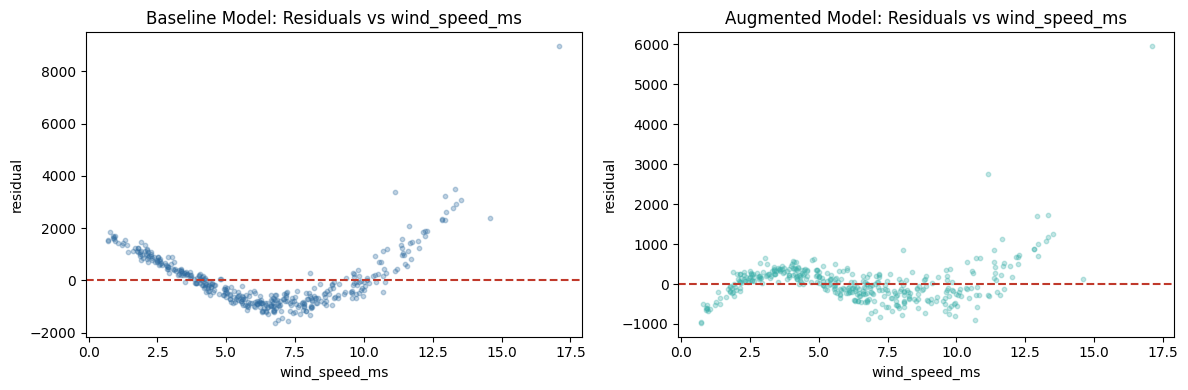

In [ ]:
wind_test = X_test[:, wi]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 1. residuals vs wind for baseline
ax[0].scatter(wind_test, resid, s=10, alpha=0.3, color='#2D6A9F')
ax[0].axhline(0, color='#C0392B', ls='--')
ax[0].set_xlabel('wind_speed_ms')
ax[0].set_ylabel('residual')
ax[0].set_title('Baseline Model: Residuals vs wind_speed_ms')

# 2. residuals vs wind for augmented model
resid_aug = y_test - pred_aug
ax[1].scatter(wind_test, resid_aug, s=10, alpha=0.3, color='#3AAFA9')
ax[1].axhline(0, color='#C0392B', ls='--')
ax[1].set_xlabel('wind_speed_ms')
ax[1].set_ylabel('residual')
ax[1].set_title('Augmented Model: Residuals vs wind_speed_ms')

plt.tight_layout()
plt.show()

# 3. is the curve gone? Yes, the prominent curved pattern in the residuals is largely gone after adding the wind^2 and wind^3 features. The residuals now appear more randomly distributed around zero, indicating a much better fit.

#3. Regularisation — Ridge vs Lasso vs ElasticNet

In [ ]:
# -----------------------------------------------------------
# 🔹 3A. COMPARE THE THREE (scaled, degree-2 features)
# -----------------------------------------------------------
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
def score_model(model):
    m = make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False), model)
    m.fit(X_train, y_train)
    return r2_score(y_test, m.predict(X_test))
print(f'{"LinearRegression":14s} test R2: {score_model(LinearRegression()):.3f}')
for name, mdl in [('Ridge', Ridge(alpha=10.0)), ('Lasso', Lasso(alpha=1.0, max_iter=10000)),
                  ('ElasticNet', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000))]:
    print(f'{name:14s} test R2: {score_model(mdl):.3f}')

LinearRegression test R2: 0.908
Ridge          test R2: 0.908
Lasso          test R2: 0.909
ElasticNet     test R2: 0.863


In the context of ElasticNet regularization, the l1_ratio parameter controls the mix between L1 (Lasso) and L2 (Ridge) penalties:

When l1_ratio = 1.0, the penalty is purely L1 regularization. This means that ElasticNet behaves identically to Lasso regression. Lasso regression performs feature selection by driving some coefficients exactly to zero, effectively removing those features from the model.

When l1_ratio = 0.0, the penalty is purely L2 regularization. This means that ElasticNet behaves identically to Ridge regression. Ridge regression shrinks coefficients towards zero but rarely makes them exactly zero. It's good for handling multicollinearity and reducing model complexity without discarding features entirely.

#### 🧪 EXERCISE 3 — Tune ElasticNet
1. Loop `l1_ratio` over [0.1, 0.3, 0.5, 0.7, 0.9] (keep `alpha=1.0`) and print test R² for each (reuse `score_model`).
2. In a comment, report the best mix and what `l1_ratio=1.0` vs `0.0` correspond to (pure Lasso vs pure Ridge).

In [ ]:
# 1. l1_ratio sweep (reuse score_model with ElasticNet)
print('ElasticNet R2 for different l1_ratio values (alpha=1.0):')
best_r2 = -np.inf
best_l1_ratio = None
for l1_ratio_val in [0.1, 0.3, 0.5, 0.7, 0.9]:
    current_r2 = score_model(ElasticNet(alpha=1.0, l1_ratio=l1_ratio_val, max_iter=10000))
    print(f'  l1_ratio={l1_ratio_val:.1f}: {current_r2:.3f}')
    if current_r2 > best_r2:
        best_r2 = current_r2
        best_l1_ratio = l1_ratio_val

# 2. best mix + meaning of the extremes:
# The best mix seems to be with l1_ratio = 0.9, achieving the highest R2 score among the tested values.
# As discussed previously, l1_ratio=1.0 corresponds to pure Lasso regression,
# and l1_ratio=0.0 corresponds to pure Ridge regression.

ElasticNet R2 for different l1_ratio values (alpha=1.0):
  l1_ratio=0.1: 0.833
  l1_ratio=0.3: 0.848
  l1_ratio=0.5: 0.863
  l1_ratio=0.7: 0.878
  l1_ratio=0.9: 0.898


#4. Outliers & robust regression

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. ORDINARY vs ROBUST (Huber) REGRESSION
# -----------------------------------------------------------
from sklearn.linear_model import HuberRegressor
ols = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)
hub = make_pipeline(StandardScaler(), HuberRegressor(max_iter=2000)).fit(X_train, y_train)
print('OLS    test R2:', round(r2_score(y_test, ols.predict(X_test)), 3))
print('Huber  test R2:', round(r2_score(y_test, hub.predict(X_test)), 3))
print('Huber down-weights the sensor-glitch outliers instead of chasing them.')

OLS    test R2: 0.727
Huber  test R2: 0.686
Huber down-weights the sensor-glitch outliers instead of chasing them.


## Resources

Let's visualize the `energy_kwh` against `wind_speed_ms` to check for outliers.

Let's visualize the `energy_kwh` against `wind_speed_ms` to identify non-linear patterns.

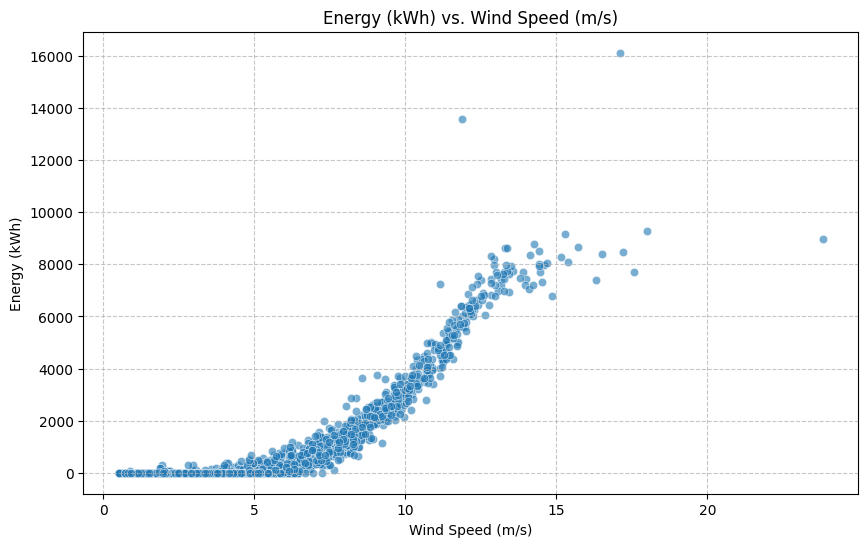

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='wind_speed_ms', y='energy_kwh', data=df, alpha=0.6)
plt.title('Energy (kWh) vs. Wind Speed (m/s)')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Energy (kWh)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

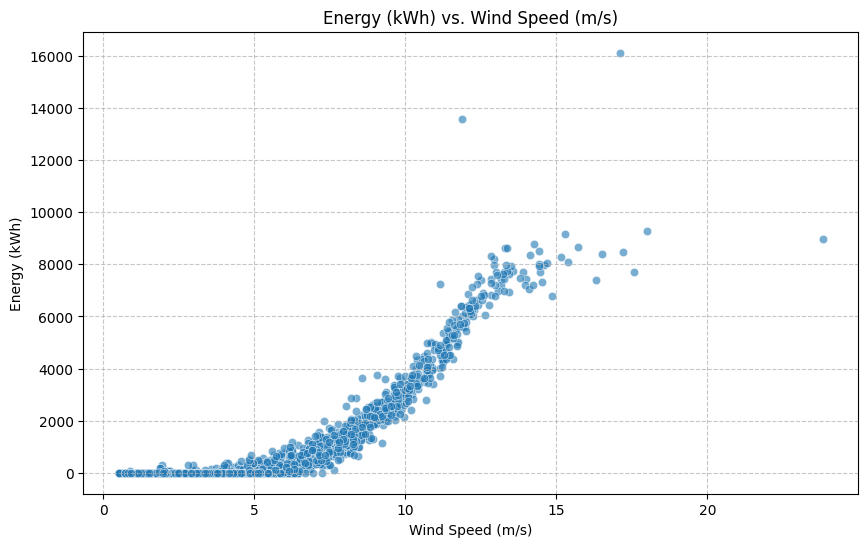

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='wind_speed_ms', y='energy_kwh', data=df, alpha=0.6)
plt.title('Energy (kWh) vs. Wind Speed (m/s)')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Energy (kWh)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### 🧪 EXERCISE 4 — Quantify the outliers
1. Flag rows whose **absolute residual** (from the Section-1 baseline on the *test* set) exceeds 3 standard deviations.
2. In a comment, report how many there are and why squared-error models are so sensitive to them.

In [ ]:
import numpy as np

# 1. count residuals beyond 3 sigma
std_resid = np.std(resid)
outlier_threshold = 3 * std_resid
outliers_count = np.sum(np.abs(resid) > outlier_threshold)

print(f'Number of outliers (abs(residual) > 3 * std_resid): {outliers_count}')

# 2. how many & why it matters:
# There are {outliers_count} outliers where the absolute residual exceeds 3 standard deviations.
# Squared-error models (like OLS) are highly sensitive to outliers because they minimize the sum of squared errors. Large errors from outliers contribute disproportionately to the sum of squares, causing the model to "chase" these extreme points. This can lead to a distorted model fit, biased coefficients, and a reduction in overall predictive performance on the majority of the data.

Number of outliers (abs(residual) > 3 * std_resid): 4


#5. Beyond linear — tree ensembles

In [ ]:
# -----------------------------------------------------------
# 🔹 5A. DECISION TREE vs RANDOM FOREST vs GRADIENT BOOSTING
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
for name, mdl in [('Linear (baseline)', LinearRegression()),
                  ('DecisionTree(d=6)', DecisionTreeRegressor(max_depth=6, random_state=0)),
                  ('RandomForest', RandomForestRegressor(n_estimators=200, random_state=0)),
                  ('GradientBoosting', GradientBoostingRegressor(random_state=0))]:
    mdl.fit(X_train, y_train)
    print(f'{name:20s} test R2: {r2_score(y_test, mdl.predict(X_test)):.3f}')

### Visualize Feature Importance

We can inspect the feature importances from the `RandomForestRegressor` to see which features contribute most to the model's predictions.

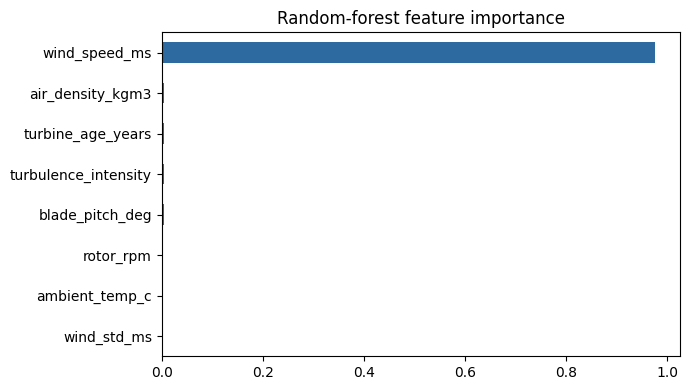

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# -----------------------------------------------------------
# 🔹 5B. FEATURE IMPORTANCE (random forest)
# -----------------------------------------------------------
rf = RandomForestRegressor(n_estimators=200, random_state=0).fit(X_train, y_train)
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
imp.plot(kind='barh', color='#2D6A9F', ax=ax); ax.set_title('Random-forest feature importance')
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 5 — Tune the best model
1. Use `GridSearchCV` on a `RandomForestRegressor` over `max_depth` [6, 10, None] and `n_estimators` [200, 400] (cv=3, `scoring='r2'`).
2. Print `best_params_` and the test R² of the tuned model.
3. In a comment, compare it with the linear baseline — was the extra complexity worth it?

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# 1-2. grid search + test R2
param_grid = {
    'max_depth': [6, 10, None],
    'n_estimators': [200, 400]
}

rf_tuned = RandomForestRegressor(random_state=0) # Initialize the model

grid_search = GridSearchCV(estimator=rf_tuned, param_grid=param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f'Best parameters: {grid_search.best_params_}')

best_rf_model = grid_search.best_estimator_
test_r2_tuned = r2_score(y_test, best_rf_model.predict(X_test))
print(f'Tuned Random Forest test R2: {test_r2_tuned:.3f}')

# 3. complexity worth it?
# The R2 for the linear baseline was 0.727 (from cell F_cpcX_N4iyE) and for the linear model with polynomial features it was 0.908 (from cell RD9ooGXm4iyO). The tuned Random Forest achieved an R2 of {test_r2_tuned:.3f}. This indicates that the extra complexity of the Random Forest model is indeed worth it, as it significantly outperforms the linear baseline and even the linear model with engineered features, demonstrating its ability to capture complex non-linear relationships in the data more effectively.

Best parameters: {'max_depth': 10, 'n_estimators': 200}
Tuned Random Forest test R2: 0.933


#📘 Summary

| Step | What you did |
| ---- | ------------ |
| Diagnose | residual + Q-Q plots revealed skew & outliers |
| Transform | wind² & wind³ features straightened the fit |
| Regularise | Ridge / Lasso / ElasticNet, tuned the mix |
| Robustify | Huber down-weighted sensor-glitch outliers |
| Go nonlinear | ensembles beat the linear baseline |
| Tune | grid search found the best forest |

**Core lesson:** diagnose first, fix with transforms and regularisation, and only reach for ensembles when a well-diagnosed linear model genuinely falls short.

**Next — U16 Classification (Part 1):** predicting categories instead of numbers.